# Privacy-decisions analysis

Loads every per-cell result JSON in `results/` into a tidy DataFrame and answers four questions:

1. **Cross-language stability per (model, scenario)** — does the same model give the same answer in every language?
2. **Cross-model agreement per (lang, scenario)** — do different models converge on the same answer?
3. **Cross-run stability per (model, lang, scenario)** — only meaningful when `RUNS_PER_CELL > 1`.
4. **Quote honesty per model** — exact / paraphrased / hallucinated-line-id breakdown.

It also loads `results_w_explanations/` for side-by-side decision-matrix and latency comparisons against the base `results/` run.

Re-running the **Load** cell after adding new models, languages, runs, or scenarios is enough — every view is rebuilt from `df` and `df_w_explanations`.


## Setup

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths are relative to the notebook (repo root). Adjust if you move the notebook.
RESULTS_DIR = Path('results')
RESULTS_W_EXPLANATIONS_DIR = Path('results_w_explanations')

# Display-order conventions. Add to these as you grow the matrix.
LANGUAGE_ORDER = ['en', 'es', 'pt-BR', 'fr', 'de', 'tr', 'ko', 'zh-CN', 'hi', 'ar', 'ur']
DECISION_ORDER = ['ALLOW', 'ALLOW AFTER VERIFICATION', 'DENY', 'ESCALATE']
RESULT_SET_ORDER = ['results', 'results_w_explanations']

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)


## Layer 0 — Load every result file into a tidy DataFrame

Each row = one `(model, language, scenario, run)` cell. Quote-verification counts are summed per cell so you don't have to re-walk the lists.

In [2]:
def load_results(results_dir: Path, result_set='results') -> pd.DataFrame:
    rows = []
    for p in sorted(Path(results_dir).rglob('*.json')):
        try:
            with p.open(encoding='utf-8') as f:
                r = json.load(f)
        except (json.JSONDecodeError, OSError):
            continue
        qv = r.get('quote_verification') or []
        match_counts = Counter(q.get('match') for q in qv)
        latencies = r.get('latency_ms') or []
        rows.append({
            'result_set': result_set,
            'model': r.get('model'),
            'language': r.get('language'),
            'scenario_id': r.get('scenario_id'),
            'run': r.get('run'),
            'decision': r.get('decision'),
            'confidence': r.get('confidence'),
            'all_quotes_verified': r.get('all_quotes_verified'),
            'n_excerpts': len(qv),
            'n_exact': match_counts.get('exact', 0),
            'n_trimmed': match_counts.get('trimmed', 0),
            'n_normalized': match_counts.get('normalized', 0),
            'n_mismatch': match_counts.get('mismatch', 0),
            'n_no_such_line_id': match_counts.get('no_such_line_id', 0),
            'n_empty_quote': match_counts.get('empty_quote', 0),
            'json_extract_reason': r.get('json_extract_reason'),
            'schema_problems': ', '.join(r.get('schema_problems') or []),
            'prompt_truncated': r.get('prompt_truncated'),
            'prompt_eval_count': r.get('prompt_eval_count'),
            'latency_ms_last': latencies[-1] if latencies else None,
            'cited_line_ids_all': ', '.join(sorted({q.get('line_id') for q in qv if q.get('line_id')})),
            'cited_line_ids_verified': ', '.join(sorted({q.get('line_id') for q in qv if q.get('ok') and q.get('line_id')})),
            'file': str(p.relative_to(results_dir)),
        })
    out = pd.DataFrame(rows)
    if out.empty:
        return out

    seen_langs = [l for l in LANGUAGE_ORDER if l in out['language'].dropna().unique()]
    extra_langs = [l for l in out['language'].dropna().unique() if l not in LANGUAGE_ORDER]
    out['language'] = pd.Categorical(out['language'], categories=seen_langs + extra_langs, ordered=True)
    out['result_set'] = pd.Categorical(out['result_set'], categories=RESULT_SET_ORDER, ordered=True)
    for maybe_bool in ['all_quotes_verified', 'prompt_truncated']:
        if maybe_bool in out.columns:
            out[maybe_bool] = out[maybe_bool].astype('object')
    for maybe_numeric in ['prompt_eval_count', 'latency_ms_last']:
        if maybe_numeric in out.columns:
            out[maybe_numeric] = pd.to_numeric(out[maybe_numeric], errors='coerce')
    return out


def summarize_loaded(name, loaded_df):
    print(f'{name}: loaded {len(loaded_df)} cells.')
    if loaded_df.empty:
        return
    print(f"  models    ({loaded_df['model'].nunique()}): {sorted(loaded_df['model'].dropna().unique())}")
    lang_values = list(loaded_df['language'].cat.categories) if hasattr(loaded_df['language'], 'cat') else sorted(loaded_df['language'].dropna().unique())
    print(f"  languages ({loaded_df['language'].nunique()}): {lang_values}")
    print(f"  scenarios ({loaded_df['scenario_id'].nunique()}): {sorted(loaded_df['scenario_id'].dropna().unique())}")
    print(f"  runs/cell:  {loaded_df.groupby(['model','language','scenario_id'], observed=True)['run'].nunique().describe()[['min','50%','max']].to_dict()}")


df = load_results(RESULTS_DIR, 'results')
df_w_explanations = load_results(RESULTS_W_EXPLANATIONS_DIR, 'results_w_explanations')
df_all = pd.concat([df, df_w_explanations], ignore_index=True)

summarize_loaded('results', df)
summarize_loaded('results_w_explanations', df_w_explanations)
df.head()


results: loaded 176 cells.
  models    (4): ['aya-expanse:8b', 'gemma3:4b', 'llama3.1:8b', 'qwen3:8b']
  languages (11): ['en', 'es', 'pt-BR', 'fr', 'de', 'tr', 'ko', 'zh-CN', 'hi', 'ar', 'ur']
  scenarios (4): ['S1', 'S2', 'S3', 'S4']
  runs/cell:  {'min': 1.0, '50%': 1.0, 'max': 1.0}
results_w_explanations: loaded 172 cells.
  models    (4): ['aya-expanse:8b', 'gemma3:4b', 'llama3.1:8b', 'qwen3:8b']
  languages (11): ['en', 'es', 'pt-BR', 'fr', 'de', 'tr', 'ko', 'zh-CN', 'hi', 'ar', 'ur']
  scenarios (4): ['S1', 'S2', 'S3', 'S4']
  runs/cell:  {'min': 1.0, '50%': 1.0, 'max': 1.0}


,result_set,model,language,scenario_id,run,decision,confidence,all_quotes_verified,n_excerpts,n_exact,n_trimmed,n_normalized,n_mismatch,n_no_such_line_id,n_empty_quote,json_extract_reason,schema_problems,prompt_truncated,prompt_eval_count,latency_ms_last,cited_line_ids_all,cited_line_ids_verified,file
0,results,aya-expanse:8b,ar,S1,1,DENY,High,None,0,0,0,0,0,0,0,direct,,None,NaN,2588.792562,,,aya-expanse-8b/aya-expanse-8b__ar__S1__run01.json
1,results,aya-expanse:8b,ar,S2,1,DENY,High,None,0,0,0,0,0,0,0,direct,,None,NaN,2589.014292,,,aya-expanse-8b/aya-expanse-8b__ar__S2__run01.json
2,results,aya-expanse:8b,ar,S3,1,DENY,High,None,0,0,0,0,0,0,0,direct,,None,NaN,2590.630770,,,aya-expanse-8b/aya-expanse-8b__ar__S3__run01.json
3,results,aya-expanse:8b,ar,S4,1,DENY,High,None,0,0,0,0,0,0,0,direct,,None,NaN,2589.710951,,,aya-expanse-8b/aya-expanse-8b__ar__S4__run01.json
4,results,aya-expanse:8b,de,S1,1,ALLOW,High,None,0,0,0,0,0,0,0,direct,,None,NaN,2553.467274,,,aya-expanse-8b/aya-expanse-8b__de__S1__run01.json


### Optional: write a flat CSV for ad-hoc Excel/pandas work

In [34]:
df.to_csv('results_flat.csv', index=False)
print(f'Wrote results_flat.csv ({len(df)} rows)')

Wrote results_flat.csv (176 rows)


## View A — Decision matrix from `results/` (model × scenario × language)

Eyeball view: a row that's the same value across all 11 columns means the model's decision is stable to translation. A mixed row means the policy translation is moving the answer.

When `RUNS_PER_CELL > 1`, each cell shows the modal decision across runs.


In [3]:
def modal(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return None
    return Counter(s).most_common(1)[0][0]


def build_decision_matrix(source_df: pd.DataFrame) -> pd.DataFrame:
    per_cell = (
        source_df.groupby(['model', 'language', 'scenario_id'], observed=True)['decision']
                 .agg(modal)
                 .reset_index()
    )
    matrix = (
        per_cell
        .pivot_table(index=['model', 'scenario_id'], columns='language',
                     values='decision', aggfunc='first', observed=True)
    )
    ordered_cols = [l for l in LANGUAGE_ORDER if l in matrix.columns]
    ordered_cols += [l for l in matrix.columns if l not in ordered_cols]
    return matrix.reindex(columns=ordered_cols)


# Collapse runs first (modal-per-cell), then pivot to model × scenario × language.
per_cell_modal = (
    df.groupby(['model', 'language', 'scenario_id'], observed=True)['decision']
      .agg(modal)
      .reset_index()
)

decision_matrix = build_decision_matrix(df)
decision_matrix_w_explanations = build_decision_matrix(df_w_explanations)
decision_matrix


language                                          en                        es                     pt-BR                        fr                        de                        tr                        ko  \
model          scenario_id                                                                                                                                                                                         
aya-expanse:8b S1                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                      DENY   
               S2                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                      DENY   
               S3                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                      DENY   
               S4                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                      DENY   
gemma3:4b      S1                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW   
               S2           ALLOW AFTER VERIFICATION                      DENY                      DENY                      DENY  ALLOW AFTER VERIFICATION                      DENY                      DENY   
               S3           ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION   
               S4                               DENY                      DENY                      DENY                      DENY                      DENY                      DENY                      DENY   
llama3.1:8b    S1                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW   
               S2                               DENY                      DENY                      DENY                      DENY                      DENY                      DENY                      DENY   
               S3           ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION  ALLOW AFTER VERIFICATION                     ALLOW   
               S4                               DENY                      DENY                      DENY                      DENY                      DENY                      DENY                      DENY   
qwen3:8b       S1                              ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW                     ALLOW   
               S2                               DENY                      DENY                      DENY                      DENY                      DENY                      DENY                      DENY   
               S3                              ALLOW                     ALLOW                     ALLOW  ALLOW AFTER VERIFICATION                     ALLOW                     ALLOW  ALLOW AFTER VERIFICATION   
               S4                               DENY                      DENY                      DENY                      DENY                      DENY                      DENY                      DENY   

language                                       zh-CN                        hi                        ar                        ur  
model          scenario_id                        

### Same matrix, color-coded

In [4]:
DECISION_COLORS = {
    'ALLOW': '#c6f6d5',
    'ALLOW AFTER VERIFICATION': '#fefcbf',
    'DENY': '#fed7d7',
    'ESCALATE': '#bee3f8',
}

def color_decision(v):
    if pd.isna(v) or v is None or v == '':
        return 'background-color: #f1f5f9; color: #94a3b8'
    return f'background-color: {DECISION_COLORS.get(v, "#ffffff")}; color: #000'

decision_matrix.style.applymap(color_decision)

/var/folders/js/z7msf4b56c18zgwd91r5ysrh0000gn/T/ipykernel_21878/595432924.py:13: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  decision_matrix.style.applymap(color_decision)


## View A2 — Decision matrix comparison: `results/` vs `results_w_explanations/`

Each cell shows the base `results/` modal decision. Cells that changed under `results_w_explanations/` are highlighted and displayed as `base -> with explanations`. `MISSING` marks a cell present in only one result set.


In [5]:
base_matrix, explanation_matrix = decision_matrix.align(decision_matrix_w_explanations, join='outer')
ordered_cols = [l for l in LANGUAGE_ORDER if l in base_matrix.columns]
ordered_cols += [l for l in base_matrix.columns if l not in ordered_cols]
base_matrix = base_matrix.reindex(columns=ordered_cols)
explanation_matrix = explanation_matrix.reindex(index=base_matrix.index, columns=base_matrix.columns)

base_display = base_matrix.astype('object').where(base_matrix.notna(), 'MISSING')
explanation_display = explanation_matrix.astype('object').where(explanation_matrix.notna(), 'MISSING')
decision_changed = base_display.ne(explanation_display)

decision_matrix_comparison = base_display.where(
    ~decision_changed,
    base_display.astype(str) + ' -> ' + explanation_display.astype(str),
)


def color_decision_comparison(_):
    styles = pd.DataFrame('', index=decision_matrix_comparison.index, columns=decision_matrix_comparison.columns)
    for idx in decision_matrix_comparison.index:
        for lang in decision_matrix_comparison.columns:
            if decision_changed.loc[idx, lang]:
                styles.loc[idx, lang] = 'background-color: #ffe8a3; color: #111827; font-weight: 600'
            else:
                value = base_matrix.loc[idx, lang]
                styles.loc[idx, lang] = color_decision(value)
    return styles

changed_count = int(decision_changed.to_numpy().sum())
total_count = int(decision_changed.size)
print(f'{changed_count} of {total_count} matrix cells changed or are missing between result sets.')
decision_matrix_comparison.style.apply(color_decision_comparison, axis=None)


54 of 176 matrix cells changed or are missing between result sets.


### Changed decision cells only

A compact long-form table of just the differences between the two decision matrices.


In [6]:
base_long = (
    base_matrix.rename_axis(index=['model', 'scenario_id'], columns='language')
               .reset_index()
               .melt(id_vars=['model', 'scenario_id'], var_name='language', value_name='decision_results')
)
explanation_long = (
    explanation_matrix.rename_axis(index=['model', 'scenario_id'], columns='language')
                      .reset_index()
                      .melt(id_vars=['model', 'scenario_id'], var_name='language', value_name='decision_w_explanations')
)

decision_changes = (
    base_long.merge(explanation_long, on=['model', 'scenario_id', 'language'], how='outer')
             .assign(
                 decision_results=lambda x: x['decision_results'].fillna('MISSING'),
                 decision_w_explanations=lambda x: x['decision_w_explanations'].fillna('MISSING'),
             )
)
decision_changes = decision_changes[
    decision_changes['decision_results'] != decision_changes['decision_w_explanations']
].sort_values(['model', 'scenario_id', 'language'])

decision_changes


,model,scenario_id,language,decision_results,decision_w_explanations
0,aya-expanse:8b,S1,ar,DENY,ALLOW
6,aya-expanse:8b,S1,ko,DENY,ALLOW
9,aya-expanse:8b,S1,ur,DENY,ALLOW
12,aya-expanse:8b,S2,de,ALLOW,DENY
13,aya-expanse:8b,S2,en,ALLOW,DENY
14,aya-expanse:8b,S2,es,ALLOW,DENY
15,aya-expanse:8b,S2,fr,ALLOW,DENY
16,aya-expanse:8b,S2,hi,ALLOW,DENY
18,aya-expanse:8b,S2,pt-BR,ALLOW,DENY
19,aya-expanse:8b,S2,tr,ALLOW,DENY


### Conflict counts by model and language

A conflict is any `(model, scenario, language)` cell where the modal decision from `results/` differs from `results_w_explanations/`, including cells that are missing from either result set.


In [7]:
decision_conflict_long = (
    decision_changed.rename_axis(index=['model', 'scenario_id'], columns='language')
                    .reset_index()
                    .melt(id_vars=['model', 'scenario_id'], var_name='language', value_name='has_conflict')
)
decision_conflict_long['has_conflict'] = decision_conflict_long['has_conflict'].astype(bool)

# Attach the actual before/after decisions so this table can also be filtered for drill-down.
decision_conflict_long = decision_conflict_long.merge(
    decision_changes,
    on=['model', 'scenario_id', 'language'],
    how='left',
)

conflict_summary_by_model = (
    decision_conflict_long.groupby('model', observed=True)
                          .agg(
                              conflicts=('has_conflict', 'sum'),
                              total_cells=('has_conflict', 'size'),
                          )
                          .assign(conflict_rate=lambda x: x['conflicts'] / x['total_cells'])
                          .sort_values(['conflicts', 'conflict_rate'], ascending=False)
)

conflict_summary_by_model.style.format({'conflict_rate': '{:.1%}'})    .background_gradient(subset=['conflict_rate'], cmap='Reds', vmin=0.0, vmax=1.0)


,conflicts,total_cells,conflict_rate
model,,,
aya-expanse:8b,22,44,50.0%
qwen3:8b,14,44,31.8%
gemma3:4b,9,44,20.5%
llama3.1:8b,9,44,20.5%


In [8]:
language_cols = [l for l in LANGUAGE_ORDER if l in decision_conflict_long['language'].astype(str).unique()]
language_cols += [l for l in decision_conflict_long['language'].astype(str).unique() if l not in language_cols]

conflict_counts_by_model_language = (
    decision_conflict_long.pivot_table(
        index='model',
        columns='language',
        values='has_conflict',
        aggfunc='sum',
        observed=True,
    )
    .reindex(columns=language_cols)
    .fillna(0)
    .astype(int)
)

conflict_counts_by_model_language['total_conflicts'] = conflict_counts_by_model_language.sum(axis=1)
conflict_counts_by_model_language = conflict_counts_by_model_language.sort_values('total_conflicts', ascending=False)

conflict_counts_by_model_language.style.background_gradient(
    subset=language_cols + ['total_conflicts'],
    cmap='Reds',
    vmin=0,
    vmax=max(1, int(conflict_counts_by_model_language[language_cols].to_numpy().max())),
)


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,total_conflicts
model,,,,,,,,,,,,
aya-expanse:8b,2,2,2,2,2,2,2,2,2,2,2,22
qwen3:8b,1,2,1,0,2,1,0,0,3,1,3,14
gemma3:4b,0,1,2,1,0,1,1,1,0,1,1,9
llama3.1:8b,0,0,0,0,0,0,1,0,4,0,4,9


In [9]:
conflict_denominators_by_model_language = (
    decision_conflict_long.pivot_table(
        index='model',
        columns='language',
        values='has_conflict',
        aggfunc='size',
        observed=True,
    )
    .reindex(index=conflict_counts_by_model_language.index, columns=language_cols)
)

conflict_rate_by_model_language = (
    conflict_counts_by_model_language[language_cols] / conflict_denominators_by_model_language
).fillna(0)
conflict_rate_by_model_language['overall_conflict_rate'] = (
    conflict_counts_by_model_language['total_conflicts'] / conflict_denominators_by_model_language.sum(axis=1)
)

conflict_rate_by_model_language.style.format('{:.1%}')    .background_gradient(cmap='Reds', vmin=0.0, vmax=1.0)


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,overall_conflict_rate
model,,,,,,,,,,,,
aya-expanse:8b,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%
qwen3:8b,25.0%,50.0%,25.0%,0.0%,50.0%,25.0%,0.0%,0.0%,75.0%,25.0%,75.0%,31.8%
gemma3:4b,0.0%,25.0%,50.0%,25.0%,0.0%,25.0%,25.0%,25.0%,0.0%,25.0%,25.0%,20.5%
llama3.1:8b,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,25.0%,0.0%,100.0%,0.0%,100.0%,20.5%


## Decision distribution per model

In [10]:
decision_dist = (
    df.groupby(['model', 'decision'], observed=True).size()
      .unstack('decision')
      .reindex(columns=DECISION_ORDER)
      .fillna(0).astype(int)
)
decision_dist['total'] = decision_dist.sum(axis=1)
decision_dist

decision,ALLOW,ALLOW AFTER VERIFICATION,DENY,ESCALATE,total
model,,,,,
aya-expanse:8b,32,0,12,0,44
gemma3:4b,10,17,17,0,44
llama3.1:8b,10,9,17,0,36
qwen3:8b,15,3,18,0,36


## Latency tables by model and language

These tables show average latency in seconds for each `model × language` cell, averaged over scenarios and runs. There is one table for the base `results/` files and one table for `results_w_explanations/`.


In [11]:
latency_compare = df_all.copy()
latency_compare['latency_ms_last'] = pd.to_numeric(latency_compare['latency_ms_last'], errors='coerce')
latency_compare['latency_sec'] = latency_compare['latency_ms_last'] / 1000
latency_clean = latency_compare.dropna(subset=['latency_sec']).copy()

latency_by_model_language = (
    latency_clean.groupby(['result_set', 'model', 'language'], observed=True)
                 .agg(
                     n=('latency_sec', 'count'),
                     avg_latency_sec=('latency_sec', 'mean'),
                     median_latency_sec=('latency_sec', 'median'),
                 )
                 .reset_index()
)

language_cols_latency = [lang for lang in LANGUAGE_ORDER if lang in latency_by_model_language['language'].astype(str).unique()]
language_cols_latency += [lang for lang in latency_by_model_language['language'].astype(str).unique() if lang not in language_cols_latency]

print(f"Latency rows used: {len(latency_clean)}")
latency_by_model_language.head()


Latency rows used: 332


,result_set,model,language,n,avg_latency_sec,median_latency_sec
0,results,aya-expanse:8b,en,4,3.806627,2.556986
1,results,aya-expanse:8b,es,4,2.559909,2.560951
2,results,aya-expanse:8b,pt-BR,4,2.555223,2.555622
3,results,aya-expanse:8b,fr,4,2.406144,2.405923
4,results,aya-expanse:8b,de,4,2.552810,2.552749


### Average latency table — `results/`

Rows are models, columns are languages, and values are average latency in seconds averaged over scenarios/runs.


In [12]:
results_latency_avg = (
    latency_by_model_language[latency_by_model_language['result_set'] == 'results']
    .pivot_table(
        index='model',
        columns='language',
        values='avg_latency_sec',
        aggfunc='first',
        observed=True,
    )
    .reindex(columns=language_cols_latency)
)
results_latency_avg['overall_avg_sec'] = results_latency_avg.mean(axis=1)
results_latency_avg = results_latency_avg.sort_values('overall_avg_sec', ascending=False)

results_latency_avg.style.format('{:.2f}', na_rep='-')    .background_gradient(cmap='Blues', subset=language_cols_latency + ['overall_avg_sec'])


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,overall_avg_sec
model,,,,,,,,,,,,
gemma3:4b,5.53,5.44,5.44,6.13,6.13,6.62,5.61,4.61,9.32,7.26,7.10,6.29
qwen3:8b,4.79,4.96,5.02,5.50,5.68,6.65,5.47,4.10,-,6.47,-,5.41
llama3.1:8b,3.93,4.24,4.29,4.66,4.83,4.63,4.26,3.78,-,5.59,-,4.47
aya-expanse:8b,3.81,2.56,2.56,2.41,2.55,2.55,2.59,2.55,2.59,2.59,2.55,2.66


### Average latency table — `results_w_explanations/`

Rows are models, columns are languages, and values are average latency in seconds averaged over scenarios/runs.


In [13]:
results_w_explanations_latency_avg = (
    latency_by_model_language[latency_by_model_language['result_set'] == 'results_w_explanations']
    .pivot_table(
        index='model',
        columns='language',
        values='avg_latency_sec',
        aggfunc='first',
        observed=True,
    )
    .reindex(columns=language_cols_latency)
)
results_w_explanations_latency_avg['overall_avg_sec'] = results_w_explanations_latency_avg.mean(axis=1)
results_w_explanations_latency_avg = results_w_explanations_latency_avg.sort_values('overall_avg_sec', ascending=False)

results_w_explanations_latency_avg.style.format('{:.2f}', na_rep='-')    .background_gradient(cmap='Oranges', subset=language_cols_latency + ['overall_avg_sec'])


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,overall_avg_sec
model,,,,,,,,,,,,
llama3.1:8b,58.31,69.69,79.00,87.67,100.25,78.22,81.68,65.72,311.29,150.32,139.83,111.09
qwen3:8b,33.26,35.80,48.45,59.62,48.60,62.30,73.27,54.69,110.81,79.28,125.96,66.55
aya-expanse:8b,17.35,19.74,20.01,19.71,18.97,19.35,19.39,16.59,29.68,21.30,23.48,20.51
gemma3:4b,9.90,12.76,10.60,10.61,10.95,12.03,11.97,11.59,14.27,16.50,13.44,12.24


### Latency difference table — `results_w_explanations` minus `results`

Positive values mean the with-explanations run was slower than the base result for that model/language. Values are seconds, averaged over scenarios/runs.


In [14]:
latency_difference_avg = results_w_explanations_latency_avg[language_cols_latency].subtract(
    results_latency_avg[language_cols_latency],
    fill_value=np.nan,
)
latency_difference_avg['overall_avg_sec'] = latency_difference_avg.mean(axis=1)
latency_difference_avg = latency_difference_avg.reindex(results_w_explanations_latency_avg.index)

latency_difference_avg.style.format('{:+.2f}', na_rep='-')    .background_gradient(cmap='Reds', subset=language_cols_latency + ['overall_avg_sec'])


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,overall_avg_sec
model,,,,,,,,,,,,
llama3.1:8b,+54.39,+65.45,+74.71,+83.01,+95.42,+73.59,+77.43,+61.94,-,+144.73,-,+81.19
qwen3:8b,+28.47,+30.83,+43.44,+54.11,+42.92,+55.66,+67.80,+50.58,-,+72.80,-,+49.62
aya-expanse:8b,+13.55,+17.19,+17.46,+17.30,+16.41,+16.80,+16.80,+14.04,+27.09,+18.71,+20.93,+17.84
gemma3:4b,+4.37,+7.32,+5.16,+4.48,+4.82,+5.41,+6.36,+6.98,+4.95,+9.24,+6.34,+5.95


### Bar plot — average latency by model

This chart summarizes the two latency tables into a report-friendly side-by-side bar plot. Each bar is the model's average latency in seconds, averaged over languages, scenarios, and runs.


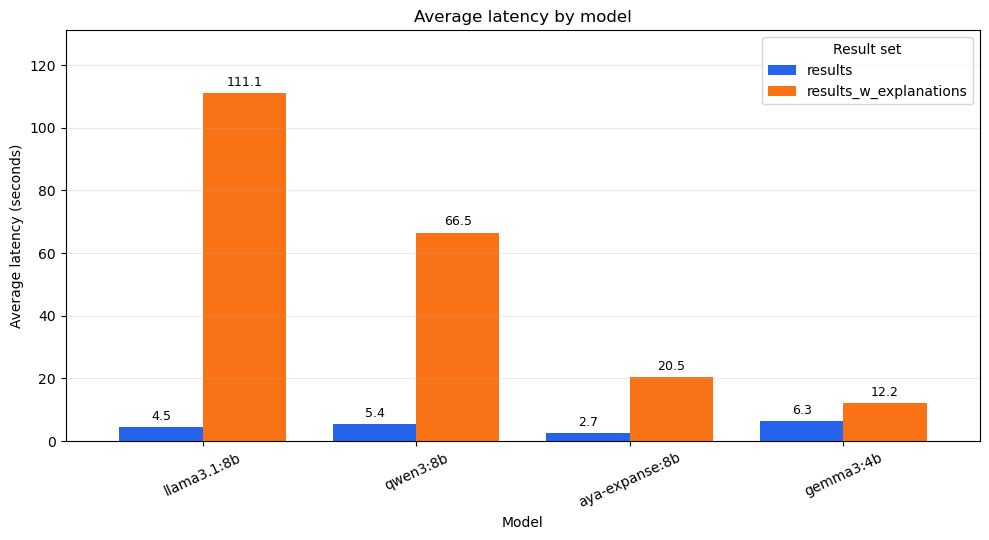

In [15]:
model_latency_bar = pd.DataFrame({
    'results': results_latency_avg['overall_avg_sec'],
    'results_w_explanations': results_w_explanations_latency_avg['overall_avg_sec'],
}).dropna(how='all')
model_latency_bar = model_latency_bar.sort_values('results_w_explanations', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
model_latency_bar.plot(
    kind='bar',
    ax=ax,
    width=0.78,
    color=['#2563eb', '#f97316'],
)

ax.set_title('Average latency by model')
ax.set_xlabel('Model')
ax.set_ylabel('Average latency (seconds)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Result set', labels=['results', 'results_w_explanations'])

max_height = float(model_latency_bar.max().max())
ax.set_ylim(0, max_height * 1.18)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### Bar plot — average latency by language

This chart summarizes average latency by language, comparing `results` and `results_w_explanations`. Each bar is averaged over models, scenarios, and runs.


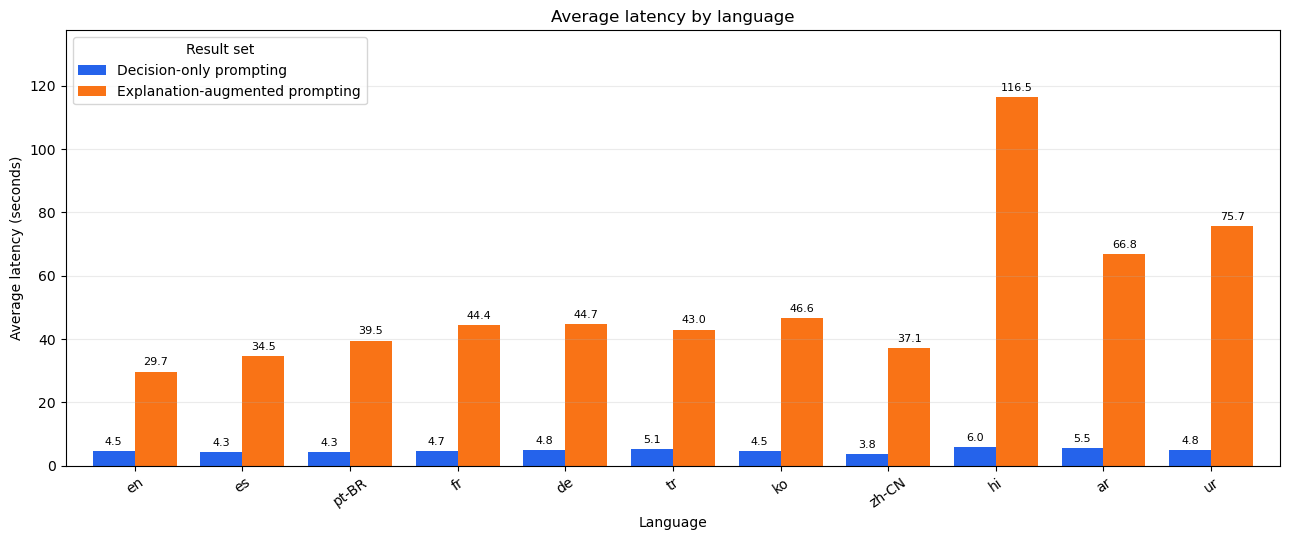

In [16]:
language_latency_bar = pd.DataFrame({
    'results': results_latency_avg[language_cols_latency].mean(axis=0),
    'results_w_explanations': results_w_explanations_latency_avg[language_cols_latency].mean(axis=0),
}).dropna(how='all')
language_latency_bar = language_latency_bar.reindex(language_cols_latency)

fig, ax = plt.subplots(figsize=(13, 5.5))
language_latency_bar.plot(
    kind='bar',
    ax=ax,
    width=0.78,
    color=['#2563eb', '#f97316'],
)

ax.set_title('Average latency by language')
ax.set_xlabel('Language')
ax.set_ylabel('Average latency (seconds)')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Result set', labels=['Decision-only prompting', 'Explanation-augmented prompting'])

max_height = float(language_latency_bar.max().max())
ax.set_ylim(0, max_height * 1.18)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()


In [17]:
# Confidence conflict analysis: results vs results_w_explanations
# This mirrors the decision conflict analysis, but compares modal confidence values.
from IPython.display import display

CONFIDENCE_ORDER = ['High', 'Medium', 'Low']


def build_confidence_matrix(source_df: pd.DataFrame) -> pd.DataFrame:
    per_cell = (
        source_df.groupby(['model', 'language', 'scenario_id'], observed=True)['confidence']
                 .agg(modal)
                 .reset_index()
    )
    matrix = (
        per_cell.pivot_table(
            index=['model', 'scenario_id'],
            columns='language',
            values='confidence',
            aggfunc='first',
            observed=True,
        )
    )
    ordered_cols = [lang for lang in LANGUAGE_ORDER if lang in matrix.columns]
    ordered_cols += [lang for lang in matrix.columns if lang not in ordered_cols]
    return matrix.reindex(columns=ordered_cols)


confidence_matrix_results = build_confidence_matrix(df)
confidence_matrix_w_explanations = build_confidence_matrix(df_w_explanations)

confidence_base, confidence_expl = confidence_matrix_results.align(
    confidence_matrix_w_explanations,
    join='outer',
)
confidence_cols = [lang for lang in LANGUAGE_ORDER if lang in confidence_base.columns]
confidence_cols += [lang for lang in confidence_base.columns if lang not in confidence_cols]
confidence_base = confidence_base.reindex(columns=confidence_cols)
confidence_expl = confidence_expl.reindex(index=confidence_base.index, columns=confidence_base.columns)

confidence_base_display = confidence_base.astype('object').where(confidence_base.notna(), 'MISSING')
confidence_expl_display = confidence_expl.astype('object').where(confidence_expl.notna(), 'MISSING')
confidence_changed = confidence_base_display.ne(confidence_expl_display)

confidence_matrix_comparison = confidence_base_display.where(
    ~confidence_changed,
    confidence_base_display.astype(str) + ' -> ' + confidence_expl_display.astype(str),
)

confidence_base_long = (
    confidence_base.rename_axis(index=['model', 'scenario_id'], columns='language')
                   .reset_index()
                   .melt(id_vars=['model', 'scenario_id'], var_name='language', value_name='confidence_results')
)
confidence_expl_long = (
    confidence_expl.rename_axis(index=['model', 'scenario_id'], columns='language')
                   .reset_index()
                   .melt(id_vars=['model', 'scenario_id'], var_name='language', value_name='confidence_w_explanations')
)

confidence_conflicts = (
    confidence_base_long.merge(confidence_expl_long, on=['model', 'scenario_id', 'language'], how='outer')
                        .assign(
                            confidence_results=lambda x: x['confidence_results'].fillna('MISSING'),
                            confidence_w_explanations=lambda x: x['confidence_w_explanations'].fillna('MISSING'),
                        )
)
confidence_conflicts = confidence_conflicts[
    confidence_conflicts['confidence_results'] != confidence_conflicts['confidence_w_explanations']
].sort_values(['model', 'scenario_id', 'language'])

confidence_conflict_long = (
    confidence_changed.rename_axis(index=['model', 'scenario_id'], columns='language')
                      .reset_index()
                      .melt(id_vars=['model', 'scenario_id'], var_name='language', value_name='has_confidence_conflict')
)
confidence_conflict_long['has_confidence_conflict'] = confidence_conflict_long['has_confidence_conflict'].astype(bool)

confidence_summary_by_model = (
    confidence_conflict_long.groupby('model', observed=True)
                            .agg(
                                confidence_conflicts=('has_confidence_conflict', 'sum'),
                                total_cells=('has_confidence_conflict', 'size'),
                            )
                            .assign(conflict_rate=lambda x: x['confidence_conflicts'] / x['total_cells'])
                            .sort_values(['confidence_conflicts', 'conflict_rate'], ascending=False)
)

confidence_counts_by_model_language = (
    confidence_conflict_long.pivot_table(
        index='model',
        columns='language',
        values='has_confidence_conflict',
        aggfunc='sum',
        observed=True,
    )
    .reindex(columns=confidence_cols)
    .fillna(0)
    .astype(int)
)
confidence_counts_by_model_language['total_conflicts'] = confidence_counts_by_model_language.sum(axis=1)
confidence_counts_by_model_language = confidence_counts_by_model_language.sort_values('total_conflicts', ascending=False)

confidence_denominators_by_model_language = (
    confidence_conflict_long.pivot_table(
        index='model',
        columns='language',
        values='has_confidence_conflict',
        aggfunc='size',
        observed=True,
    )
    .reindex(index=confidence_counts_by_model_language.index, columns=confidence_cols)
)
confidence_rate_by_model_language = (
    confidence_counts_by_model_language[confidence_cols] / confidence_denominators_by_model_language
).fillna(0)
confidence_rate_by_model_language['overall_conflict_rate'] = (
    confidence_counts_by_model_language['total_conflicts'] / confidence_denominators_by_model_language.sum(axis=1)
)

confidence_transition_counts = (
    confidence_conflicts.groupby(['confidence_results', 'confidence_w_explanations'], observed=True)
                        .size()
                        .rename('n')
                        .reset_index()
                        .sort_values('n', ascending=False)
)

total_confidence_cells = int(confidence_changed.size)
total_confidence_conflicts = int(confidence_changed.to_numpy().sum())
print(f'Confidence conflicts: {total_confidence_conflicts} of {total_confidence_cells} cells ({total_confidence_conflicts / total_confidence_cells:.1%}).')

print('\nConfidence conflict summary by model:')
display(
    confidence_summary_by_model.style.format({'conflict_rate': '{:.1%}'})
                               .background_gradient(subset=['conflict_rate'], cmap='Reds', vmin=0.0, vmax=1.0)
)

print('\nConfidence conflict counts by model and language:')
display(
    confidence_counts_by_model_language.style.background_gradient(
        subset=confidence_cols + ['total_conflicts'],
        cmap='Reds',
        vmin=0,
        vmax=max(1, int(confidence_counts_by_model_language[confidence_cols].to_numpy().max())),
    )
)

print('\nConfidence conflict rates by model and language:')
display(
    confidence_rate_by_model_language.style.format('{:.1%}')
                                          .background_gradient(cmap='Reds', vmin=0.0, vmax=1.0)
)

print('\nMost common confidence transitions:')
display(confidence_transition_counts)

print('\nChanged confidence cells only:')
display(confidence_conflicts)


Confidence conflicts: 48 of 176 cells (27.3%).

Confidence conflict summary by model:


,confidence_conflicts,total_cells,conflict_rate
model,,,
gemma3:4b,17,44,38.6%
llama3.1:8b,17,44,38.6%
qwen3:8b,14,44,31.8%
aya-expanse:8b,0,44,0.0%



Confidence conflict counts by model and language:


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,total_conflicts
model,,,,,,,,,,,,
gemma3:4b,1,2,3,2,0,1,2,3,1,1,1,17
llama3.1:8b,0,2,2,1,1,1,1,0,4,1,4,17
qwen3:8b,1,2,1,0,2,1,0,0,3,1,3,14
aya-expanse:8b,0,0,0,0,0,0,0,0,0,0,0,0



Confidence conflict rates by model and language:


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,overall_conflict_rate
model,,,,,,,,,,,,
gemma3:4b,25.0%,50.0%,75.0%,50.0%,0.0%,25.0%,50.0%,75.0%,25.0%,25.0%,25.0%,38.6%
llama3.1:8b,0.0%,50.0%,50.0%,25.0%,25.0%,25.0%,25.0%,0.0%,100.0%,25.0%,100.0%,38.6%
qwen3:8b,25.0%,50.0%,25.0%,0.0%,50.0%,25.0%,0.0%,0.0%,75.0%,25.0%,75.0%,31.8%
aya-expanse:8b,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%



Most common confidence transitions:


,confidence_results,confidence_w_explanations,n
1,High,Medium,23
3,MISSING,High,15
0,High,MISSING,6
4,MISSING,Medium,2
2,Low,Medium,1
5,Medium,MISSING,1



Changed confidence cells only:


,model,scenario_id,language,confidence_results,confidence_w_explanations
47,gemma3:4b,S1,es,MISSING,High
51,gemma3:4b,S1,pt-BR,MISSING,Medium
52,gemma3:4b,S1,tr,High,Medium
54,gemma3:4b,S1,zh-CN,High,Medium
55,gemma3:4b,S2,ar,High,Medium
58,gemma3:4b,S2,es,High,Medium
59,gemma3:4b,S2,fr,High,Medium
61,gemma3:4b,S2,ko,High,Medium
62,gemma3:4b,S2,pt-BR,High,Medium
65,gemma3:4b,S2,zh-CN,Low,Medium


## Confidence score plots

Encode confidence as `High = 2`, `Medium = 1`, and `Low = 0`, then average the score to compare `results/` and `results_w_explanations/`. Higher bars mean higher average reported confidence.


In [18]:
CONFIDENCE_SCORE = {'High': 2, 'Medium': 1, 'Low': 0}

confidence_score_df = df_all.copy()
confidence_score_df['confidence_score'] = confidence_score_df['confidence'].map(CONFIDENCE_SCORE)
confidence_score_df = confidence_score_df.dropna(subset=['confidence_score']).copy()
confidence_score_df['confidence_score'] = confidence_score_df['confidence_score'].astype(float)

confidence_score_summary = (
    confidence_score_df.groupby(['result_set', 'model', 'language'], observed=True)
                       .agg(
                           n=('confidence_score', 'count'),
                           avg_confidence_score=('confidence_score', 'mean'),
                       )
                       .reset_index()
)

print(f'Confidence-scored rows used: {len(confidence_score_df)}')
confidence_score_summary.head()


Confidence-scored rows used: 324


,result_set,model,language,n,avg_confidence_score
0,results,aya-expanse:8b,en,4,2.0
1,results,aya-expanse:8b,es,4,2.0
2,results,aya-expanse:8b,pt-BR,4,2.0
3,results,aya-expanse:8b,fr,4,2.0
4,results,aya-expanse:8b,de,4,2.0


### Bar plot — average confidence score by model

Each bar is the average encoded confidence score for a model, averaged over languages, scenarios, and runs.


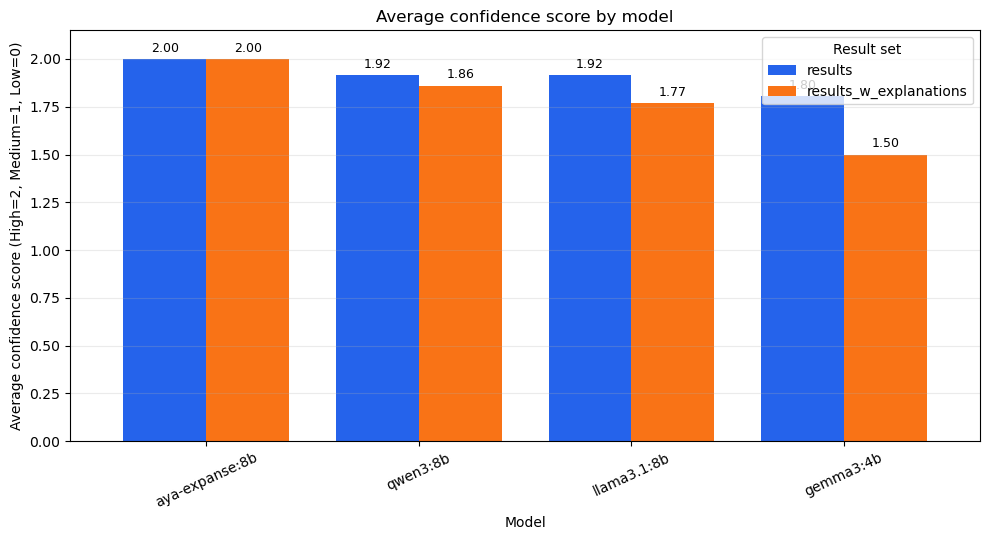

In [19]:
model_confidence_bar = (
    confidence_score_df.groupby(['model', 'result_set'], observed=True)['confidence_score']
                       .mean()
                       .unstack('result_set')
)
model_confidence_bar = model_confidence_bar.reindex(columns=['results', 'results_w_explanations'])
model_confidence_bar = model_confidence_bar.sort_values('results_w_explanations', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
model_confidence_bar.plot(
    kind='bar',
    ax=ax,
    width=0.78,
    color=['#2563eb', '#f97316'],
)

ax.set_title('Average confidence score by model')
ax.set_xlabel('Model')
ax.set_ylabel('Average confidence score (High=2, Medium=1, Low=0)')
ax.set_ylim(0, 2.15)
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Result set', labels=['results', 'results_w_explanations'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### Bar plot — average confidence score by language

Each bar is the average encoded confidence score for a language, averaged over models, scenarios, and runs.


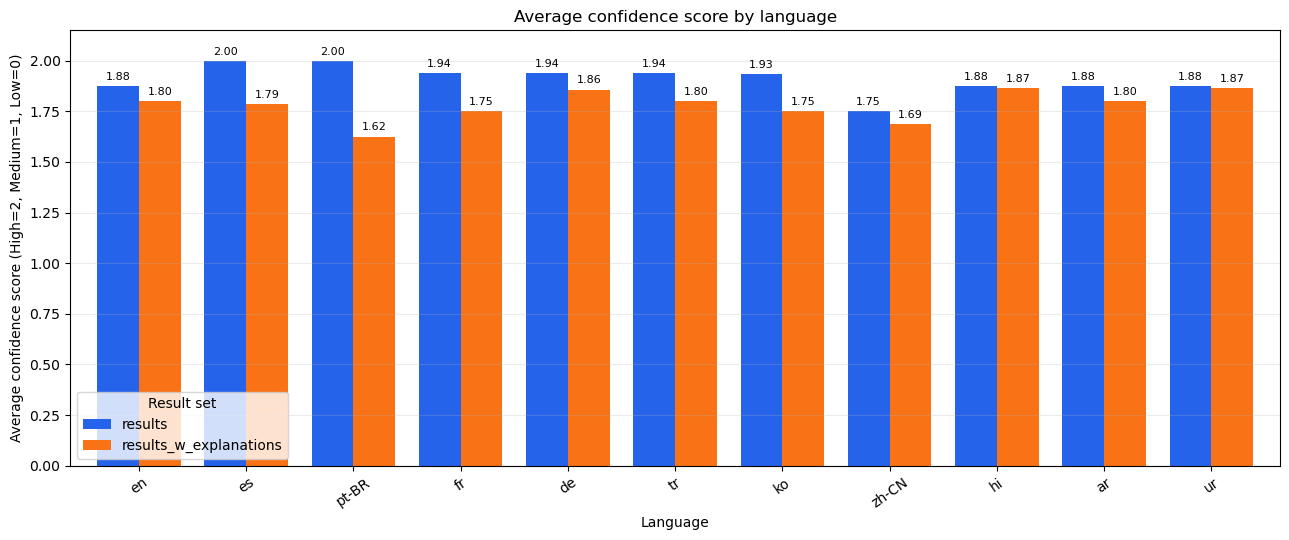

In [20]:
language_confidence_bar = (
    confidence_score_df.groupby(['language', 'result_set'], observed=True)['confidence_score']
                       .mean()
                       .unstack('result_set')
)
language_confidence_bar = language_confidence_bar.reindex([lang for lang in LANGUAGE_ORDER if lang in language_confidence_bar.index])
language_confidence_bar = language_confidence_bar.reindex(columns=['results', 'results_w_explanations'])

fig, ax = plt.subplots(figsize=(13, 5.5))
language_confidence_bar.plot(
    kind='bar',
    ax=ax,
    width=0.78,
    color=['#2563eb', '#f97316'],
)

ax.set_title('Average confidence score by language')
ax.set_xlabel('Language')
ax.set_ylabel('Average confidence score (High=2, Medium=1, Low=0)')
ax.set_ylim(0, 2.15)
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Result set', labels=['results', 'results_w_explanations'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()


## GPT-5.5 ground-truth decision comparison

`results_gpt5.5/` is treated as the ground truth. This section compares every model decision in `results/` and `results_w_explanations/` against the GPT-5.5 decision for the same `(language, scenario_id)` cell.


In [21]:
from IPython.display import display

RESULTS_GPT55_DIR = Path('results_gpt5.5')

df_gpt55 = load_results(RESULTS_GPT55_DIR, 'gpt-5.5_ground_truth')
print(f'Loaded GPT-5.5 ground truth cells: {len(df_gpt55)}')
print(f"  languages ({df_gpt55['language'].nunique()}): {list(df_gpt55['language'].cat.categories) if hasattr(df_gpt55['language'], 'cat') else sorted(df_gpt55['language'].dropna().unique())}")
print(f"  scenarios ({df_gpt55['scenario_id'].nunique()}): {sorted(df_gpt55['scenario_id'].dropna().unique())}")

gpt55_per_cell = (
    df_gpt55.groupby(['language', 'scenario_id'], observed=True)['decision']
            .agg(modal)
            .reset_index()
            .rename(columns={'decision': 'gpt55_decision'})
)

gpt55_decision_matrix = (
    gpt55_per_cell.pivot_table(
        index='scenario_id',
        columns='language',
        values='gpt55_decision',
        aggfunc='first',
        observed=True,
    )
)
gpt55_cols = [lang for lang in LANGUAGE_ORDER if lang in gpt55_decision_matrix.columns]
gpt55_cols += [lang for lang in gpt55_decision_matrix.columns if lang not in gpt55_cols]
gpt55_decision_matrix = gpt55_decision_matrix.reindex(columns=gpt55_cols)

gpt55_decision_matrix.style.applymap(color_decision)


Loaded GPT-5.5 ground truth cells: 44
  languages (11): ['en', 'es', 'pt-BR', 'fr', 'de', 'tr', 'ko', 'zh-CN', 'hi', 'ar', 'ur']
  scenarios (4): ['S1', 'S2', 'S3', 'S4']


/var/folders/js/z7msf4b56c18zgwd91r5ysrh0000gn/T/ipykernel_21878/558778988.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  gpt55_decision_matrix.style.applymap(color_decision)


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur
scenario_id,,,,,,,,,,,
S1,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW,ALLOW
S2,DENY,DENY,DENY,DENY,DENY,DENY,DENY,DENY,DENY,DENY,DENY
S3,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION,ALLOW AFTER VERIFICATION
S4,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE,ESCALATE


### Model decisions versus GPT-5.5 ground truth

A conflict means the model's modal decision differs from GPT-5.5 for the same language and scenario. Missing or unparsable model decisions are counted as conflicts because they do not match the ground-truth decision.


In [22]:
candidate_decisions = (
    df_all.groupby(['result_set', 'model', 'language', 'scenario_id'], observed=True)['decision']
          .agg(modal)
          .reset_index()
          .rename(columns={'decision': 'model_decision'})
)

result_sets_for_gt = [x for x in RESULT_SET_ORDER if x in df_all['result_set'].astype(str).unique()]
models_for_gt = sorted(df_all['model'].dropna().unique())
gt_keys = gpt55_per_cell[['language', 'scenario_id']].drop_duplicates()
expected_gt_rows = (
    pd.MultiIndex.from_product(
        [result_sets_for_gt, models_for_gt],
        names=['result_set', 'model'],
    )
    .to_frame(index=False)
    .merge(gt_keys, how='cross')
)

model_vs_gpt55 = (
    expected_gt_rows.merge(candidate_decisions, on=['result_set', 'model', 'language', 'scenario_id'], how='left')
                    .merge(gpt55_per_cell, on=['language', 'scenario_id'], how='left')
)
model_vs_gpt55['model_decision_display'] = model_vs_gpt55['model_decision'].fillna('MISSING_OR_NO_DECISION')
model_vs_gpt55['gpt55_decision_display'] = model_vs_gpt55['gpt55_decision'].fillna('MISSING_GPT55')
model_vs_gpt55['conflicts_with_gpt55'] = (
    model_vs_gpt55['model_decision_display'] != model_vs_gpt55['gpt55_decision_display']
)
model_vs_gpt55['matches_gpt55'] = ~model_vs_gpt55['conflicts_with_gpt55']

conflicts_vs_gpt55 = model_vs_gpt55[model_vs_gpt55['conflicts_with_gpt55']].copy()

gpt55_conflict_summary = (
    model_vs_gpt55.groupby(['result_set', 'model'], observed=True)
                  .agg(
                      conflicts=('conflicts_with_gpt55', 'sum'),
                      matches=('matches_gpt55', 'sum'),
                      total_cells=('conflicts_with_gpt55', 'size'),
                  )
                  .assign(
                      conflict_rate=lambda x: x['conflicts'] / x['total_cells'],
                      match_rate=lambda x: x['matches'] / x['total_cells'],
                  )
                  .sort_values(['result_set', 'conflict_rate', 'conflicts'], ascending=[True, False, False])
)

print(f"Total comparisons against GPT-5.5: {len(model_vs_gpt55)}")
print(f"Total conflicts against GPT-5.5: {int(model_vs_gpt55['conflicts_with_gpt55'].sum())}")

display(
    gpt55_conflict_summary.style.format({'conflict_rate': '{:.1%}', 'match_rate': '{:.1%}'})
                                .background_gradient(subset=['conflict_rate'], cmap='Reds', vmin=0.0, vmax=1.0)
                                .background_gradient(subset=['match_rate'], cmap='Greens', vmin=0.0, vmax=1.0)
)


Total comparisons against GPT-5.5: 352
Total conflicts against GPT-5.5: 171


### Conflict counts by model and language versus GPT-5.5

The first table is for base `results/`; the second table is for `results_w_explanations/`.


In [23]:
def conflict_counts_by_model_language(source_name):
    subset = model_vs_gpt55[model_vs_gpt55['result_set'].astype(str) == source_name]
    table = (
        subset.pivot_table(
            index='model',
            columns='language',
            values='conflicts_with_gpt55',
            aggfunc='sum',
            observed=True,
        )
        .reindex(columns=gpt55_cols)
        .fillna(0)
        .astype(int)
    )
    table['total_conflicts'] = table.sum(axis=1)
    return table.sort_values('total_conflicts', ascending=False)

results_conflicts_vs_gpt55_by_language = conflict_counts_by_model_language('results')
results_w_explanations_conflicts_vs_gpt55_by_language = conflict_counts_by_model_language('results_w_explanations')

print('results/ conflicts vs GPT-5.5')
display(
    results_conflicts_vs_gpt55_by_language.style.background_gradient(
        subset=gpt55_cols + ['total_conflicts'],
        cmap='Reds',
        vmin=0,
        vmax=max(1, int(results_conflicts_vs_gpt55_by_language[gpt55_cols].to_numpy().max())),
    )
)

print('results_w_explanations/ conflicts vs GPT-5.5')
display(
    results_w_explanations_conflicts_vs_gpt55_by_language.style.background_gradient(
        subset=gpt55_cols + ['total_conflicts'],
        cmap='Reds',
        vmin=0,
        vmax=max(1, int(results_w_explanations_conflicts_vs_gpt55_by_language[gpt55_cols].to_numpy().max())),
    )
)


results/ conflicts vs GPT-5.5


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,total_conflicts
model,,,,,,,,,,,,
aya-expanse:8b,3,3,3,3,3,3,3,3,3,3,3,33
qwen3:8b,2,2,2,1,2,2,1,1,4,2,4,23
llama3.1:8b,1,1,1,1,1,1,2,1,4,2,4,19
gemma3:4b,2,1,1,1,2,1,1,2,2,1,3,17


results_w_explanations/ conflicts vs GPT-5.5


language,en,es,pt-BR,fr,de,tr,ko,zh-CN,hi,ar,ur,total_conflicts
model,,,,,,,,,,,,
gemma3:4b,2,2,3,2,2,2,2,3,2,2,2,24
aya-expanse:8b,2,2,2,2,2,2,2,2,2,2,2,22
qwen3:8b,2,2,1,1,2,2,1,1,2,1,2,17
llama3.1:8b,1,1,1,1,1,1,1,1,3,2,3,16


### Which result set is closer to GPT-5.5?

Negative `conflict_delta_w_explanations_minus_results` means explanations reduced conflicts versus GPT-5.5. Positive means explanations increased conflicts.


In [24]:
gpt55_conflict_summary_flat = gpt55_conflict_summary.reset_index()
comparison_vs_gpt55 = (
    gpt55_conflict_summary_flat.pivot_table(
        index='model',
        columns='result_set',
        values=['conflicts', 'conflict_rate', 'matches', 'match_rate', 'total_cells'],
        aggfunc='first',
        observed=True,
    )
)

closer_to_gpt55 = pd.DataFrame(index=comparison_vs_gpt55.index)
closer_to_gpt55['results_conflicts'] = comparison_vs_gpt55[('conflicts', 'results')]
closer_to_gpt55['results_w_explanations_conflicts'] = comparison_vs_gpt55[('conflicts', 'results_w_explanations')]
closer_to_gpt55['conflict_delta_w_explanations_minus_results'] = (
    closer_to_gpt55['results_w_explanations_conflicts'] - closer_to_gpt55['results_conflicts']
)
closer_to_gpt55['results_match_rate'] = comparison_vs_gpt55[('match_rate', 'results')]
closer_to_gpt55['results_w_explanations_match_rate'] = comparison_vs_gpt55[('match_rate', 'results_w_explanations')]
closer_to_gpt55['match_rate_delta_w_explanations_minus_results'] = (
    closer_to_gpt55['results_w_explanations_match_rate'] - closer_to_gpt55['results_match_rate']
)
closer_to_gpt55 = closer_to_gpt55.sort_values('conflict_delta_w_explanations_minus_results')

display(
    closer_to_gpt55.style.format({
        'results_match_rate': '{:.1%}',
        'results_w_explanations_match_rate': '{:.1%}',
        'match_rate_delta_w_explanations_minus_results': '{:+.1%}',
    }).background_gradient(
        subset=['conflict_delta_w_explanations_minus_results'],
        cmap='RdYlGn_r',
    ).background_gradient(
        subset=['match_rate_delta_w_explanations_minus_results'],
        cmap='RdYlGn',
    )
)


,results_conflicts,results_w_explanations_conflicts,conflict_delta_w_explanations_minus_results,results_match_rate,results_w_explanations_match_rate,match_rate_delta_w_explanations_minus_results
model,,,,,,
aya-expanse:8b,33,22,-11,25.0%,50.0%,+25.0%
qwen3:8b,23,17,-6,47.7%,61.4%,+13.6%
llama3.1:8b,19,16,-3,56.8%,63.6%,+6.8%
gemma3:4b,17,24,7,61.4%,45.5%,-15.9%


### Changed cells only — model decision versus GPT-5.5

Long-form drill-down table of every model cell that conflicts with GPT-5.5.


In [25]:
conflicts_vs_gpt55_display = conflicts_vs_gpt55[[
    'result_set',
    'model',
    'language',
    'scenario_id',
    'model_decision_display',
    'gpt55_decision_display',
]].sort_values(['result_set', 'model', 'scenario_id', 'language'])

conflicts_vs_gpt55_display


,result_set,model,language,scenario_id,model_decision_display,gpt55_decision_display
24,results,aya-expanse:8b,ko,S1,DENY,ALLOW
36,results,aya-expanse:8b,ar,S1,DENY,ALLOW
40,results,aya-expanse:8b,ur,S1,DENY,ALLOW
1,results,aya-expanse:8b,en,S2,ALLOW,DENY
5,results,aya-expanse:8b,es,S2,ALLOW,DENY
9,results,aya-expanse:8b,pt-BR,S2,ALLOW,DENY
13,results,aya-expanse:8b,fr,S2,ALLOW,DENY
17,results,aya-expanse:8b,de,S2,ALLOW,DENY
21,results,aya-expanse:8b,tr,S2,ALLOW,DENY
29,results,aya-expanse:8b,zh-CN,S2,ALLOW,DENY


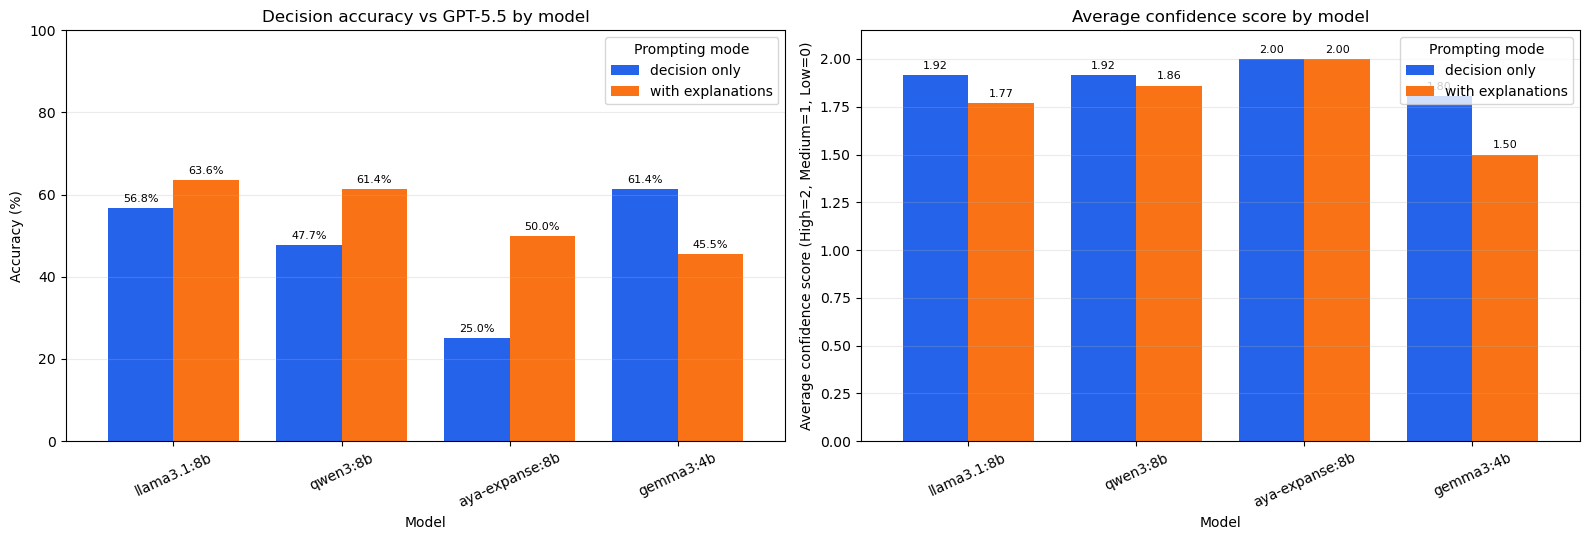

Accuracy vs GPT-5.5 by model:


result_set,decision only,with explanations,delta_with_explanations_minus_decision_only
model,,,
llama3.1:8b,56.8%,63.6%,+6.8%
qwen3:8b,47.7%,61.4%,+13.6%
aya-expanse:8b,25.0%,50.0%,+25.0%
gemma3:4b,61.4%,45.5%,-15.9%


Average confidence score by model:


result_set,decision only,with explanations,delta_with_explanations_minus_decision_only
model,,,
llama3.1:8b,1.92,1.77,-0.15
qwen3:8b,1.92,1.86,-0.06
aya-expanse:8b,2.00,2.00,+0.00
gemma3:4b,1.80,1.50,-0.30


In [26]:
# Final report plot: accuracy vs GPT-5.5 and confidence by model
# Compares decision-only prompting (`results`) with explanation-augmented prompting (`results_w_explanations`).
from IPython.display import display

# Fallbacks make this cell runnable as long as the setup/load/modal cells were run.
if 'df_gpt55' not in globals():
    RESULTS_GPT55_DIR = Path('results_gpt5.5')
    df_gpt55 = load_results(RESULTS_GPT55_DIR, 'gpt-5.5_ground_truth')

if 'gpt55_per_cell' not in globals():
    gpt55_per_cell = (
        df_gpt55.groupby(['language', 'scenario_id'], observed=True)['decision']
                .agg(modal)
                .reset_index()
                .rename(columns={'decision': 'gpt55_decision'})
    )

RESULT_SET_LABELS = {
    'results': 'decision only',
    'results_w_explanations': 'with explanations',
}
plot_result_sets = ['results', 'results_w_explanations']

# Accuracy: compare each model/result_set decision to GPT-5.5 for every ground-truth language/scenario.
# Missing or unparsable model decisions are counted as incorrect.
candidate_decisions_for_plot = (
    df_all[df_all['result_set'].astype(str).isin(plot_result_sets)]
    .groupby(['result_set', 'model', 'language', 'scenario_id'], observed=True)['decision']
    .agg(modal)
    .reset_index()
    .rename(columns={'decision': 'model_decision'})
)

models_for_plot = sorted(candidate_decisions_for_plot['model'].dropna().unique())
gt_keys = gpt55_per_cell[['language', 'scenario_id']].drop_duplicates()
expected_rows_for_plot = (
    pd.MultiIndex.from_product(
        [plot_result_sets, models_for_plot],
        names=['result_set', 'model'],
    )
    .to_frame(index=False)
    .merge(gt_keys, how='cross')
)

accuracy_vs_gpt55_plot_df = (
    expected_rows_for_plot.merge(
        candidate_decisions_for_plot,
        on=['result_set', 'model', 'language', 'scenario_id'],
        how='left',
    )
    .merge(gpt55_per_cell, on=['language', 'scenario_id'], how='left')
)
accuracy_vs_gpt55_plot_df['is_correct'] = (
    accuracy_vs_gpt55_plot_df['model_decision'] == accuracy_vs_gpt55_plot_df['gpt55_decision']
)

accuracy_by_model_result_set = (
    accuracy_vs_gpt55_plot_df.groupby(['model', 'result_set'], observed=True)
                             .agg(
                                 correct=('is_correct', 'sum'),
                                 total=('is_correct', 'size'),
                             )
                             .assign(accuracy=lambda x: x['correct'] / x['total'])
                             .reset_index()
)

accuracy_bar = (
    accuracy_by_model_result_set.pivot_table(
        index='model',
        columns='result_set',
        values='accuracy',
        aggfunc='first',
        observed=True,
    )
    .reindex(columns=plot_result_sets)
)
accuracy_bar = accuracy_bar.sort_values('results_w_explanations', ascending=False)

# Confidence: High=2, Medium=1, Low=0 for both result sets.
CONFIDENCE_SCORE = {'High': 2, 'Medium': 1, 'Low': 0}
confidence_for_plot = df_all[df_all['result_set'].astype(str).isin(plot_result_sets)].copy()
confidence_for_plot['confidence_score'] = confidence_for_plot['confidence'].map(CONFIDENCE_SCORE)
confidence_for_plot = confidence_for_plot.dropna(subset=['confidence_score']).copy()
confidence_for_plot['confidence_score'] = confidence_for_plot['confidence_score'].astype(float)

confidence_bar = (
    confidence_for_plot.groupby(['model', 'result_set'], observed=True)['confidence_score']
                       .mean()
                       .unstack('result_set')
                       .reindex(index=accuracy_bar.index, columns=plot_result_sets)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

accuracy_bar.rename(columns=RESULT_SET_LABELS).mul(100).plot(
    kind='bar',
    ax=axes[0],
    width=0.78,
    color=['#2563eb', '#f97316'],
)
axes[0].set_title('Decision accuracy vs GPT-5.5 by model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(title='Prompting mode')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

confidence_bar.rename(columns=RESULT_SET_LABELS).plot(
    kind='bar',
    ax=axes[1],
    width=0.78,
    color=['#2563eb', '#f97316'],
)
axes[1].set_title('Average confidence score by model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Average confidence score (High=2, Medium=1, Low=0)')
axes[1].set_ylim(0, 2.15)
axes[1].tick_params(axis='x', rotation=25)
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(title='Prompting mode')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

accuracy_summary_table = accuracy_bar.rename(columns=RESULT_SET_LABELS).copy()
accuracy_summary_table['delta_with_explanations_minus_decision_only'] = (
    accuracy_bar['results_w_explanations'] - accuracy_bar['results']
)

confidence_summary_table = confidence_bar.rename(columns=RESULT_SET_LABELS).copy()
confidence_summary_table['delta_with_explanations_minus_decision_only'] = (
    confidence_bar['results_w_explanations'] - confidence_bar['results']
)

print('Accuracy vs GPT-5.5 by model:')
display(
    accuracy_summary_table.style.format({
        'decision only': '{:.1%}',
        'with explanations': '{:.1%}',
        'delta_with_explanations_minus_decision_only': '{:+.1%}',
    })
)

print('Average confidence score by model:')
display(
    confidence_summary_table.style.format({
        'decision only': '{:.2f}',
        'with explanations': '{:.2f}',
        'delta_with_explanations_minus_decision_only': '{:+.2f}',
    })
)


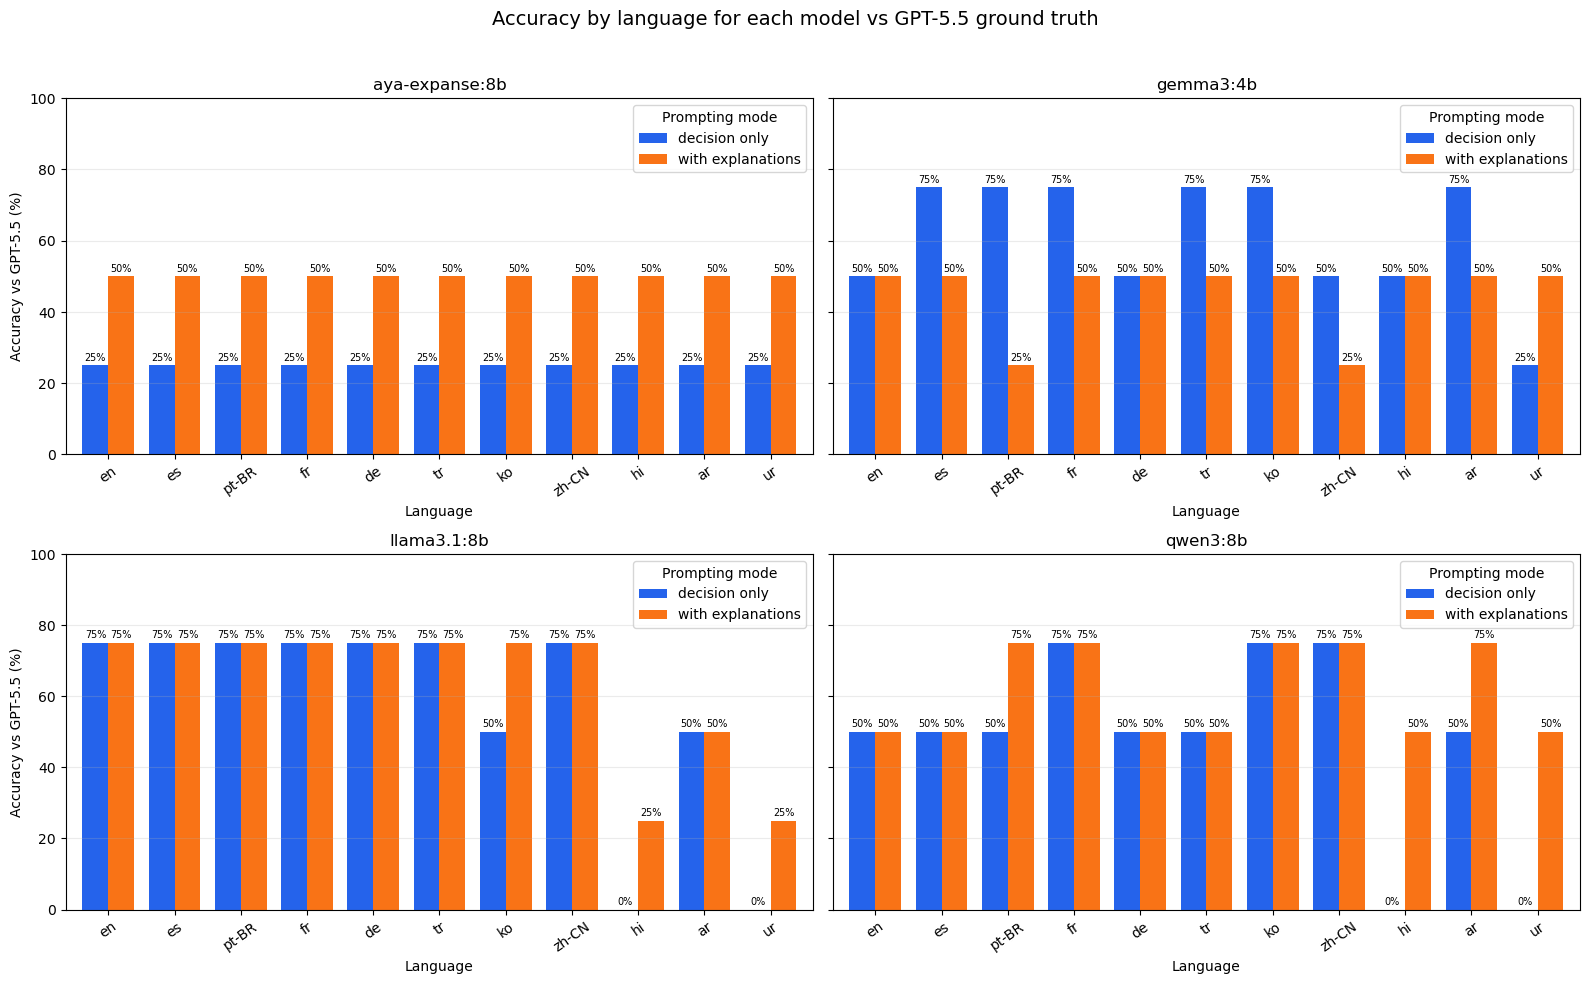

Accuracy by model and language vs GPT-5.5:


result_set,model,language,decision only,with explanations,delta_with_explanations_minus_decision_only
0,aya-expanse:8b,en,25.0%,50.0%,+25.0%
1,aya-expanse:8b,es,25.0%,50.0%,+25.0%
2,aya-expanse:8b,pt-BR,25.0%,50.0%,+25.0%
3,aya-expanse:8b,fr,25.0%,50.0%,+25.0%
4,aya-expanse:8b,de,25.0%,50.0%,+25.0%
5,aya-expanse:8b,tr,25.0%,50.0%,+25.0%
6,aya-expanse:8b,ko,25.0%,50.0%,+25.0%
7,aya-expanse:8b,zh-CN,25.0%,50.0%,+25.0%
8,aya-expanse:8b,hi,25.0%,50.0%,+25.0%
9,aya-expanse:8b,ar,25.0%,50.0%,+25.0%


In [27]:
# Accuracy across languages for each model, using GPT-5.5 as ground truth
# Compares decision-only prompting (`results`) with explanation-augmented prompting (`results_w_explanations`).
from IPython.display import display

if 'df_gpt55' not in globals():
    RESULTS_GPT55_DIR = Path('results_gpt5.5')
    df_gpt55 = load_results(RESULTS_GPT55_DIR, 'gpt-5.5_ground_truth')

if 'gpt55_per_cell' not in globals():
    gpt55_per_cell = (
        df_gpt55.groupby(['language', 'scenario_id'], observed=True)['decision']
                .agg(modal)
                .reset_index()
                .rename(columns={'decision': 'gpt55_decision'})
    )

RESULT_SET_LABELS = {
    'results': 'decision only',
    'results_w_explanations': 'with explanations',
}
plot_result_sets = ['results', 'results_w_explanations']

candidate_decisions_by_language = (
    df_all[df_all['result_set'].astype(str).isin(plot_result_sets)]
    .groupby(['result_set', 'model', 'language', 'scenario_id'], observed=True)['decision']
    .agg(modal)
    .reset_index()
    .rename(columns={'decision': 'model_decision'})
)

models_for_language_accuracy = sorted(candidate_decisions_by_language['model'].dropna().unique())
gt_keys = gpt55_per_cell[['language', 'scenario_id']].drop_duplicates()
expected_language_accuracy_rows = (
    pd.MultiIndex.from_product(
        [plot_result_sets, models_for_language_accuracy],
        names=['result_set', 'model'],
    )
    .to_frame(index=False)
    .merge(gt_keys, how='cross')
)

language_accuracy_vs_gpt55 = (
    expected_language_accuracy_rows.merge(
        candidate_decisions_by_language,
        on=['result_set', 'model', 'language', 'scenario_id'],
        how='left',
    )
    .merge(gpt55_per_cell, on=['language', 'scenario_id'], how='left')
)
language_accuracy_vs_gpt55['is_correct'] = (
    language_accuracy_vs_gpt55['model_decision'] == language_accuracy_vs_gpt55['gpt55_decision']
)

accuracy_by_model_language_result_set = (
    language_accuracy_vs_gpt55.groupby(['model', 'language', 'result_set'], observed=True)
                              .agg(
                                  correct=('is_correct', 'sum'),
                                  total=('is_correct', 'size'),
                              )
                              .assign(accuracy=lambda x: x['correct'] / x['total'])
                              .reset_index()
)

language_order_for_accuracy = [lang for lang in LANGUAGE_ORDER if lang in accuracy_by_model_language_result_set['language'].astype(str).unique()]
language_order_for_accuracy += [
    lang for lang in accuracy_by_model_language_result_set['language'].astype(str).unique()
    if lang not in language_order_for_accuracy
]

# Reader-friendly table: one row per model/language with both prompting modes and delta.
accuracy_by_model_language_table = (
    accuracy_by_model_language_result_set.pivot_table(
        index=['model', 'language'],
        columns='result_set',
        values='accuracy',
        aggfunc='first',
        observed=True,
    )
    .reindex(columns=plot_result_sets)
    .rename(columns=RESULT_SET_LABELS)
)
accuracy_by_model_language_table['delta_with_explanations_minus_decision_only'] = (
    accuracy_by_model_language_table['with explanations'] - accuracy_by_model_language_table['decision only']
)
accuracy_by_model_language_table = accuracy_by_model_language_table.reset_index()
accuracy_by_model_language_table['language'] = pd.Categorical(
    accuracy_by_model_language_table['language'],
    categories=language_order_for_accuracy,
    ordered=True,
)
accuracy_by_model_language_table = accuracy_by_model_language_table.sort_values(['model', 'language'])

# Bar plots: one subplot per model, language on x-axis, two bars per language.
models_sorted_for_plot = sorted(models_for_language_accuracy)
n_models = len(models_sorted_for_plot)
ncols = 2
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.8 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, model in zip(axes, models_sorted_for_plot):
    model_plot = (
        accuracy_by_model_language_result_set[accuracy_by_model_language_result_set['model'] == model]
        .pivot_table(
            index='language',
            columns='result_set',
            values='accuracy',
            aggfunc='first',
            observed=True,
        )
        .reindex(language_order_for_accuracy)
        .reindex(columns=plot_result_sets)
        .rename(columns=RESULT_SET_LABELS)
    )
    model_plot.mul(100).plot(
        kind='bar',
        ax=ax,
        width=0.78,
        color=['#2563eb', '#f97316'],
    )
    ax.set_title(model)
    ax.set_xlabel('Language')
    ax.set_ylabel('Accuracy vs GPT-5.5 (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title='Prompting mode')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=7)

for ax in axes[n_models:]:
    ax.axis('off')

fig.suptitle('Accuracy by language for each model vs GPT-5.5 ground truth', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print('Accuracy by model and language vs GPT-5.5:')
display(
    accuracy_by_model_language_table.style.format({
        'decision only': '{:.1%}',
        'with explanations': '{:.1%}',
        'delta_with_explanations_minus_decision_only': '{:+.1%}',
    })
)
